**Logistic Regression: MLE and MAP Derivation**

$$
P(y=1 \mid x_i) = \sigma(\theta^T x_i)
$$

$$
P(y_i \mid x_i) =
\begin{cases}
\sigma(\theta^T x_i) & \text{if } y_i = 1 \\
1 - \sigma(\theta^T x_i) & \text{if } y_i = 0
\end{cases}
$$

$$
P(y_i \mid x_i) = \sigma(\theta^T x_i)^{y_i} (1 - \sigma(\theta^T x_i))^{1 - y_i}
$$

$$
L(\theta) = \prod_{i=1}^n \sigma(\theta^T x_i)^{y_i} (1 - \sigma(\theta^T x_i))^{1 - y_i}
$$

$$
\ell(\theta) = \log L(\theta) = \sum_{i=1}^n \Bigl[ y_i \log \sigma(\theta^T x_i) + (1-y_i) \log (1 - \sigma(\theta^T x_i)) \Bigr]
$$

$$
\hat{\theta}_{\text{MLE}} = \arg\max_\theta L(\theta) = \arg\min_\theta -\ell(\theta)
\quad\text{(log is strictly increasing)}
$$

**Bayes' Theorem:**

$$
P(\theta \mid D) = \frac{P(D \mid \theta) P(\theta)}{P(D)} \propto P(D \mid \theta) P(\theta)
\quad\text{(P(D) is constant)}
$$

**MAP Estimation (assuming normal prior):**

$$
\begin{aligned}
\hat{\theta}_{\text{MAP}}
&= \arg\max_{\theta} \, P(\theta \mid D) \\
&= \arg\max_{\theta} \, P(D \mid \theta) \, P(\theta) \\
&= \arg\max_{\theta} \Bigl[ \log P(D \mid \theta) + \log P(\theta) \Bigr] && \text{(log is strictly increasing)} \\
&= \arg\max_{\theta} \Bigl[ \ell(\theta) + \log P(\theta) \Bigr] \\
&= \arg\max_{\theta} \Bigl[ \ell(\theta) - \frac{1}{2\sigma^2} \sum_{j=1}^d \theta_j^2\Bigr] \\
&= \arg\max_{\theta} \Bigl[ \ell(\theta) - \frac{1}{2\sigma^2} \|\theta\|_2^2 \Bigr] \\
&= \arg\min_{\theta} \Bigl[ -\ell(\theta) + \frac{\lambda}{2} \|\theta\|_2^2 \Bigr] && \text{with } \lambda = \frac{1}{\sigma^2}
\end{aligned}
$$

**The Gaussian prior is**

$$
P(\theta) = \prod_{j=1}^d \frac{1}{\sqrt{2\pi \sigma^2}} \exp\left( -\frac{\theta_j^2}{2\sigma^2} \right)
\quad\text{or equivalently}\quad
P(\theta) \propto \exp\left( -\frac{\|\theta\|_2^2}{2\sigma^2} \right)
$$

**Assumptions**

- Labels $y_i \in \{0, 1\}$
- Training examples are IID (independent and identically distributed)
- No large multicollinearity
- MAP assumes Gaussian (normal) prior on weights
- The problem can be modeled by the logistic function

T1)
1) Above derivation. This technique is different from MLE because of the regularization term that assumes that weights come from a normal distribution. What this means is that weights too high in amplitude are too unlikely therefore they contribute to loss. https://www.dataversity.net/articles/regularization-for-logistic-regression-l1-l2-gauss-or-laplace explains how assuming a normal model creates L2 regularization. The article also shows that this improved their model accuracy a lot. In https://web.engr.oregonstate.edu/~xfern/classes/cs534-18/Logistic-Regression-3-updated.pdf they show the gradient formula which reveals what is really happening. Basically, when a weight gets larger it has a gradient that tries to push that weight back to a smaller value. In practice this would prevent specific features from being considered too heavily and causing a collapse to relying only on a single feature rather than evenly weighing many features which could improve generalization.
2) Classifying molecules if they are active or inactive at androgen receptors. Logistic regression is the best choice because it works well with imbalanced classes (In this dataset the class split is about 4% active 96% inactive). It also outputs between 0 and 1 which we use for binary classification. Additionally, it works well with high dimensional data even when there isn't many data points. (We have 7566 data points with 384 features). Compared to a technique like deep learning, this approach will be much faster since the training and evaluation process is very simple and involves much fewer weights and biases than a typical deep learning model. Deep learning tends to require much more data as well, otherwise there would be a significant risk of overfitting, where the model memorizes training data rather than extracting meaningful patterns. https://www.geeksforgeeks.org/deep-learning/advantages-and-disadvantages-of-deep-learning/
3) So our assumptions were: IID data points - molecules come from the same dataset and are unique and not reliant on eachother. labels are 0 or 1 - yes 0 indicates that the molecule does not exhibit AR activity, 1 indicates that it does. no large multicollinearity - it is possible that our data does contain large multicollinearity so I will have to perform analysis or data cleaning methods such as PCA. assuming it can be modeled by a logistic formula - it is possible that the data will be too complex or not have relationships that can be modeled logistically but because our data points have so many features that can be combined in many ways I think that we should see at least some success in being able to classify accurately. In the derivation, x would represent the features, which in our case will be an embedding representation of a molecule and y would represent the label where 1 iff it exhibits AR activity.

In [1]:
import sys
if sys.version_info[:2] != (3,11):
    raise Exception("Must be using Python 3.11. Deepchem is not compatible with newer versions of python. If on Colab switch to 2025.07 runtime version")

In [2]:
pip install rdkit deepchem numpy torch transformers scikit-learn statsmodels seaborn plotly umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 73.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12


In [3]:
import deepchem as dc
import numpy as np
tasks, datasets, transformers = dc.molnet.load_tox21(
    featurizer='ECFP',
    splitter='scaffold' #Split the molecules into training/test, stratifying by their molecular structure
)

train_dataset, valid_dataset, test_dataset = datasets

#Identify which task is the NR-AR task
task_idx = tasks.index('NR-AR')

#Get the SMILE data from the data points (The molecular representation like "CCO")
def extract_smiles_and_labels(dataset, task_idx):
    y = dataset.y[:, task_idx]
    w = dataset.w[:, task_idx]

    #Remove molecules with a missing label...
    mask = w.flatten() > 0
    smiles = dataset.ids[mask].tolist()
    labels = y[mask]
    return smiles, labels

smiles_train, y_train = extract_smiles_and_labels(train_dataset, task_idx)
smiles_valid, y_valid = extract_smiles_and_labels(valid_dataset, task_idx)
smiles_test,  y_test  = extract_smiles_and_labels(test_dataset,  task_idx)

#For now combine the validation and train data
smiles_train_full = smiles_train + smiles_valid
y_train_full = np.concatenate([y_train, y_valid])

print(f"Train samples: {len(y_train_full)} (active molecules: {y_train_full.sum()})")
print(f"Test samples:  {len(y_test)} (active molecules: {y_test.sum()})")

Streaming output truncated to the last 5000 lines.
[20:15:54] DEPRECATION WARNING: please use MorganGenerator
[20:15:54] DEPRECATION WARNING: please use MorganGenerator
[20:15:54] DEPRECATION WARNING: please use MorganGenerator
[20:15:54] DEPRECATION WARNING: please use MorganGenerator
[20:15:54] DEPRECATION WARNING: please use MorganGenerator
[20:15:54] DEPRECATION WARNING: please use MorganGenerator
[20:15:54] DEPRECATION WARNING: please use MorganGenerator
[20:15:54] DEPRECATION WARNING: please use MorganGenerator
[20:15:54] DEPRECATION WARNING: please use MorganGenerator
[20:15:54] DEPRECATION WARNING: please use MorganGenerator
[20:15:54] DEPRECATION WARNING: please use MorganGenerator
[20:15:54] DEPRECATION WARNING: please use MorganGenerator
[20:15:54] DEPRECATION WARNING: please use MorganGenerator
[20:15:54] DEPRECATION WARNING: please use MorganGenerator
[20:15:54] DEPRECATION WARNING: please use MorganGenerator
[20:15:54] DEPRECATION WARNING: please use MorganGenerator
[20:1

Train samples: 6543 (active molecules: 281.0)
Test samples:  715 (active molecules: 27.0)


In [4]:
import torch
from transformers import AutoTokenizer, AutoModel
#Load ChemBERTa for embeddings
model_name = "DeepChem/ChemBERTa-77M-MTR"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

def get_embedding(smiles):
    tokenized = tokenizer(smiles, return_tensors="pt", padding=True, truncation=True, max_length=512)
    with torch.no_grad():
        input_ids = tokenized["input_ids"]
        attention_mask = tokenized["attention_mask"]
        outputs = model(input_ids,attention_mask)
        # Mean over token embeddings
        emb = outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
        return emb

def compute_embeddings(smiles_list):
    embeddings = []
    for smi in smiles_list:
        emb = get_embedding(smi)
        if emb is not None:
            embeddings.append(emb)
    return np.array(embeddings)

print("Computing train embeddings")
X_train = compute_embeddings(smiles_train_full)

print("Computing test embeddings")
X_test = compute_embeddings(smiles_test)
print("--- Embedding stats ---");
minimum_val = np.minimum(np.min(X_train), np.min(X_test))
maximum_val = np.maximum(np.max(X_train), np.max(X_test))
print(f"Embeddings: [{minimum_val}, {maximum_val}]")



/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/14.0M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MTR and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Computing train embeddings


model.safetensors:   0%|          | 0.00/14.0M [00:00<?, ?B/s]

Computing test embeddings
--- Embedding stats ---
Embeddings: [-4.779587268829346, 4.238003253936768]


T2)
1) Tox21 NR-AR dataset https://tox21.gov/data-and-tools/ Molecular formulas are embedded using the publicly available ChemBERTa-77M-MTR https://huggingface.co/DeepChem/ChemBERTa-77M-MTR/tree/main into 384 features
2) The VIF values here are massive (e9+) initially which indicates that there must be some significant source of multicollinearity. I iteratively removed the highest VIF feature until all VIF<=10.0. The code below takes very long to run but removes many features leaving just 131 features, which I've hard-coded alongside the commented out full algorithm so that it doesn't take 6+ hours again.
3) Visualized using a clustered correlation heatmap and then pair plots using a histogram (KDE is impossibly slow for even just a few features it seems.). In the heatmap we see that features 44 66 46 3 12 72 have high correlations as their specific rows show high correlation with many other features forming a rectangular pattern. In the pair plots, we see that on the diagonal all of the features are approximately normally distributed, or at least mostly symmetric with a single peak in the center. What this means is that our data is well distributed but that its not likely any single feature would highly differentiate our classes. This could mean that our dataset is a good fit for using a logistic regression because its unlikely that the correlation between a feature and the output has a very complex relationship. In some of the feature pairs we see that the 2d gaussian is a normal symmetric cloud of points in a circular shape. However, some of the plots are clearly slanted, indicating some linear correlation. In some, like plot (f3,f5), we see a part sticking out towards the bottom right which could be signs of a distinction between the two classes or it could just be due to randomness.

In [5]:
import pandas as pd
'''print("This will take a while!")
from sklearn.preprocessing import StandardScaler

def calculate_vif(X, thresh=10.0):
    X_scaled_df = pd.DataFrame(StandardScaler().fit_transform(X), columns=[f'feature{i}' for i in range(X.shape[1])])
    while True:
        #Compute the vif which takes very long
        vif = pd.DataFrame()
        vif['feature'] = X_scaled_df.columns
        vif['VIF'] = [variance_inflation_factor(X_scaled_df.values, i) for i in range(X_scaled_df.shape[1])]
        max_vif = vif['VIF'].max()
        #If the vif is larger than 10 remove the column and repeat.
        if max_vif > thresh:
            drop_feature = vif.loc[vif['VIF'] == max_vif, 'feature'].values[0]
            print(f"Dropping {drop_feature} with VIF={max_vif}")
            X_scaled_df = X_scaled_df.drop(columns=[drop_feature])
        else:
            break
    return X_scaled_df, vif

X_clean, final_vif = calculate_vif(X_train)
print(final_vif)'''

#Precomputed list of enabled features with <10 VIF
enabled_features = [0,2,10,12,15,18,19,20,21,26,29,30,36,38,39,43,44,47,48,50,51,52,54,56,62,63,67,68,69,74,77,78,80,84,87,89,96,98,106,110,111,114,115,118,119,120,123,124,125,130,132,133,138,139,142,145,148,152,153,158,160,162,163,168,171,172,175,180,183,184,185,188,198,199,201,205,209,211,213,216,218,219,227,233,236,238,243,244,253,257,260,265,266,270,272,276,283,285,293,294,302,306,307,310,315,320,322,324,326,327,330,331,333,338,339,340,341,345,353,354,359,360,361,362,366,371,372,374,376,381,383]
X_train_final = X_train[:, enabled_features]
X_test_final = X_test[:, enabled_features]
print("Features reduced.")

Features reduced.


Top 20 features most correlated with target (absolute corr):
3      0.207293
118    0.193887
5      0.175994
88     0.167868
127    0.166129
33     0.157860
101    0.156939
72     0.153433
69     0.145004
36     0.140090
7      0.139870
117    0.137895
12     0.137206
27     0.134450
104    0.129211
6      0.128275
103    0.127500
44     0.127071
46     0.125366
66     0.122919
Name: target, dtype: float64


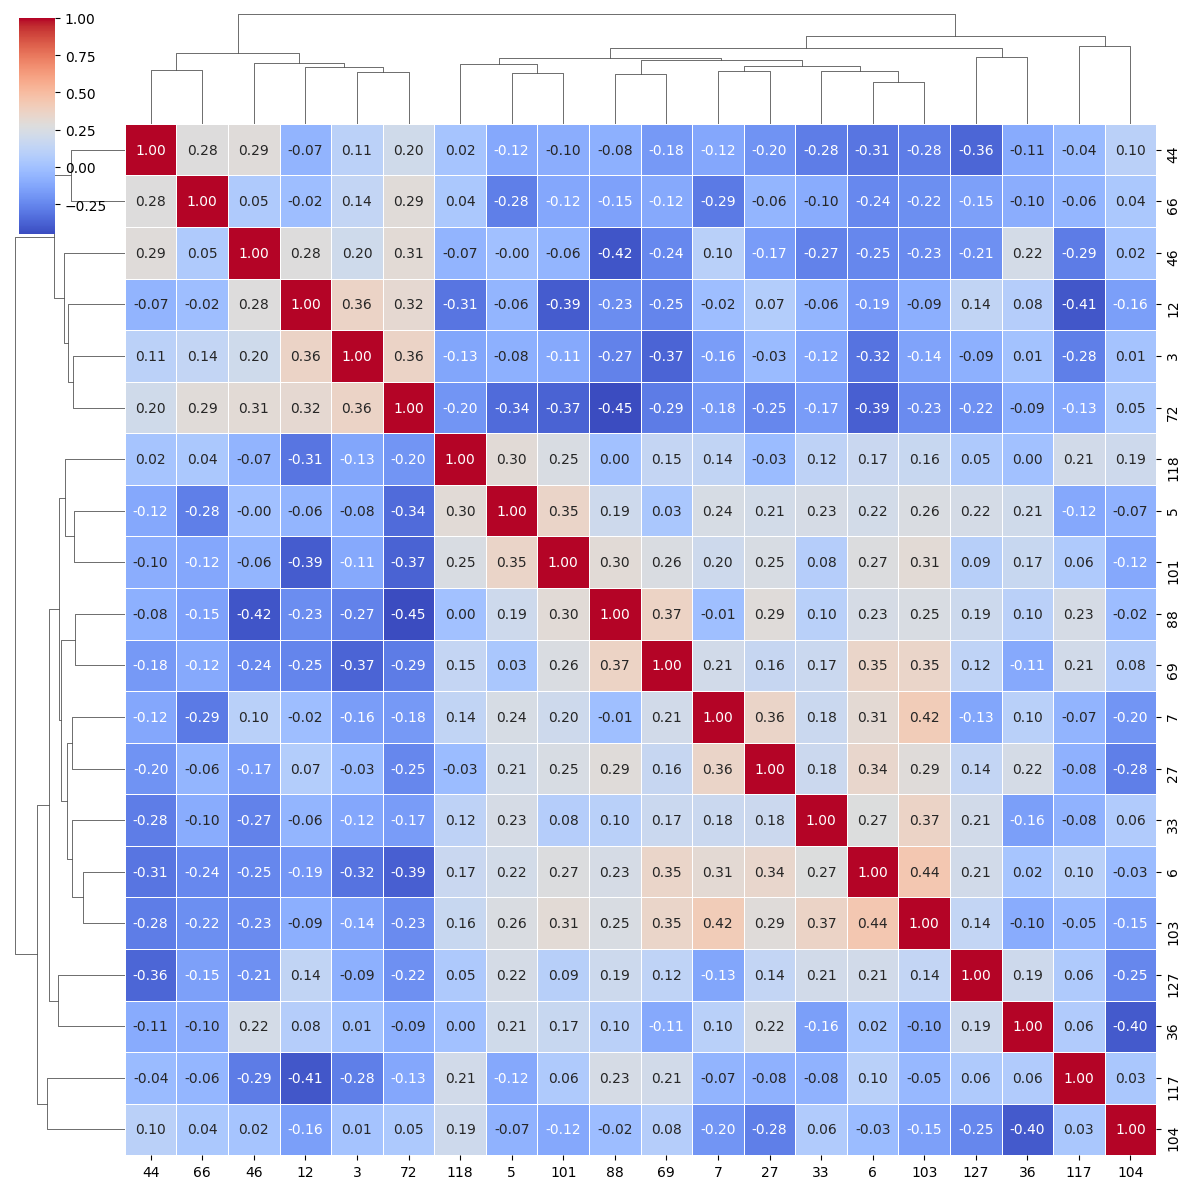

In [6]:
%matplotlib inline
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

#Beyond 20 the pairplot graph takes extremely long to generate
TOP_N_FEATURES = 20

pd_x_train_final = pd.DataFrame(X_train_final)
df_with_target = pd_x_train_final.copy()
df_with_target["target"] = y_train_full

corr_full = df_with_target.corr()
corr_with_target = corr_full["target"].abs().sort_values(ascending=False)
top_features = corr_with_target.index.drop("target")[:TOP_N_FEATURES].tolist()

print(f"Top {TOP_N_FEATURES} features most correlated with target (absolute corr):")
print(corr_with_target[top_features])

X_top = pd_x_train_final[top_features].copy()

X_top_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X_top),
    columns=X_top.columns
)

corr_top = X_top_scaled.corr()

sns.clustermap(
    corr_top,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    dendrogram_ratio=0.1,
    cbar_pos=(0.02, 0.8, 0.03, 0.18),
    figsize=(12, 12)
)

plt.show()

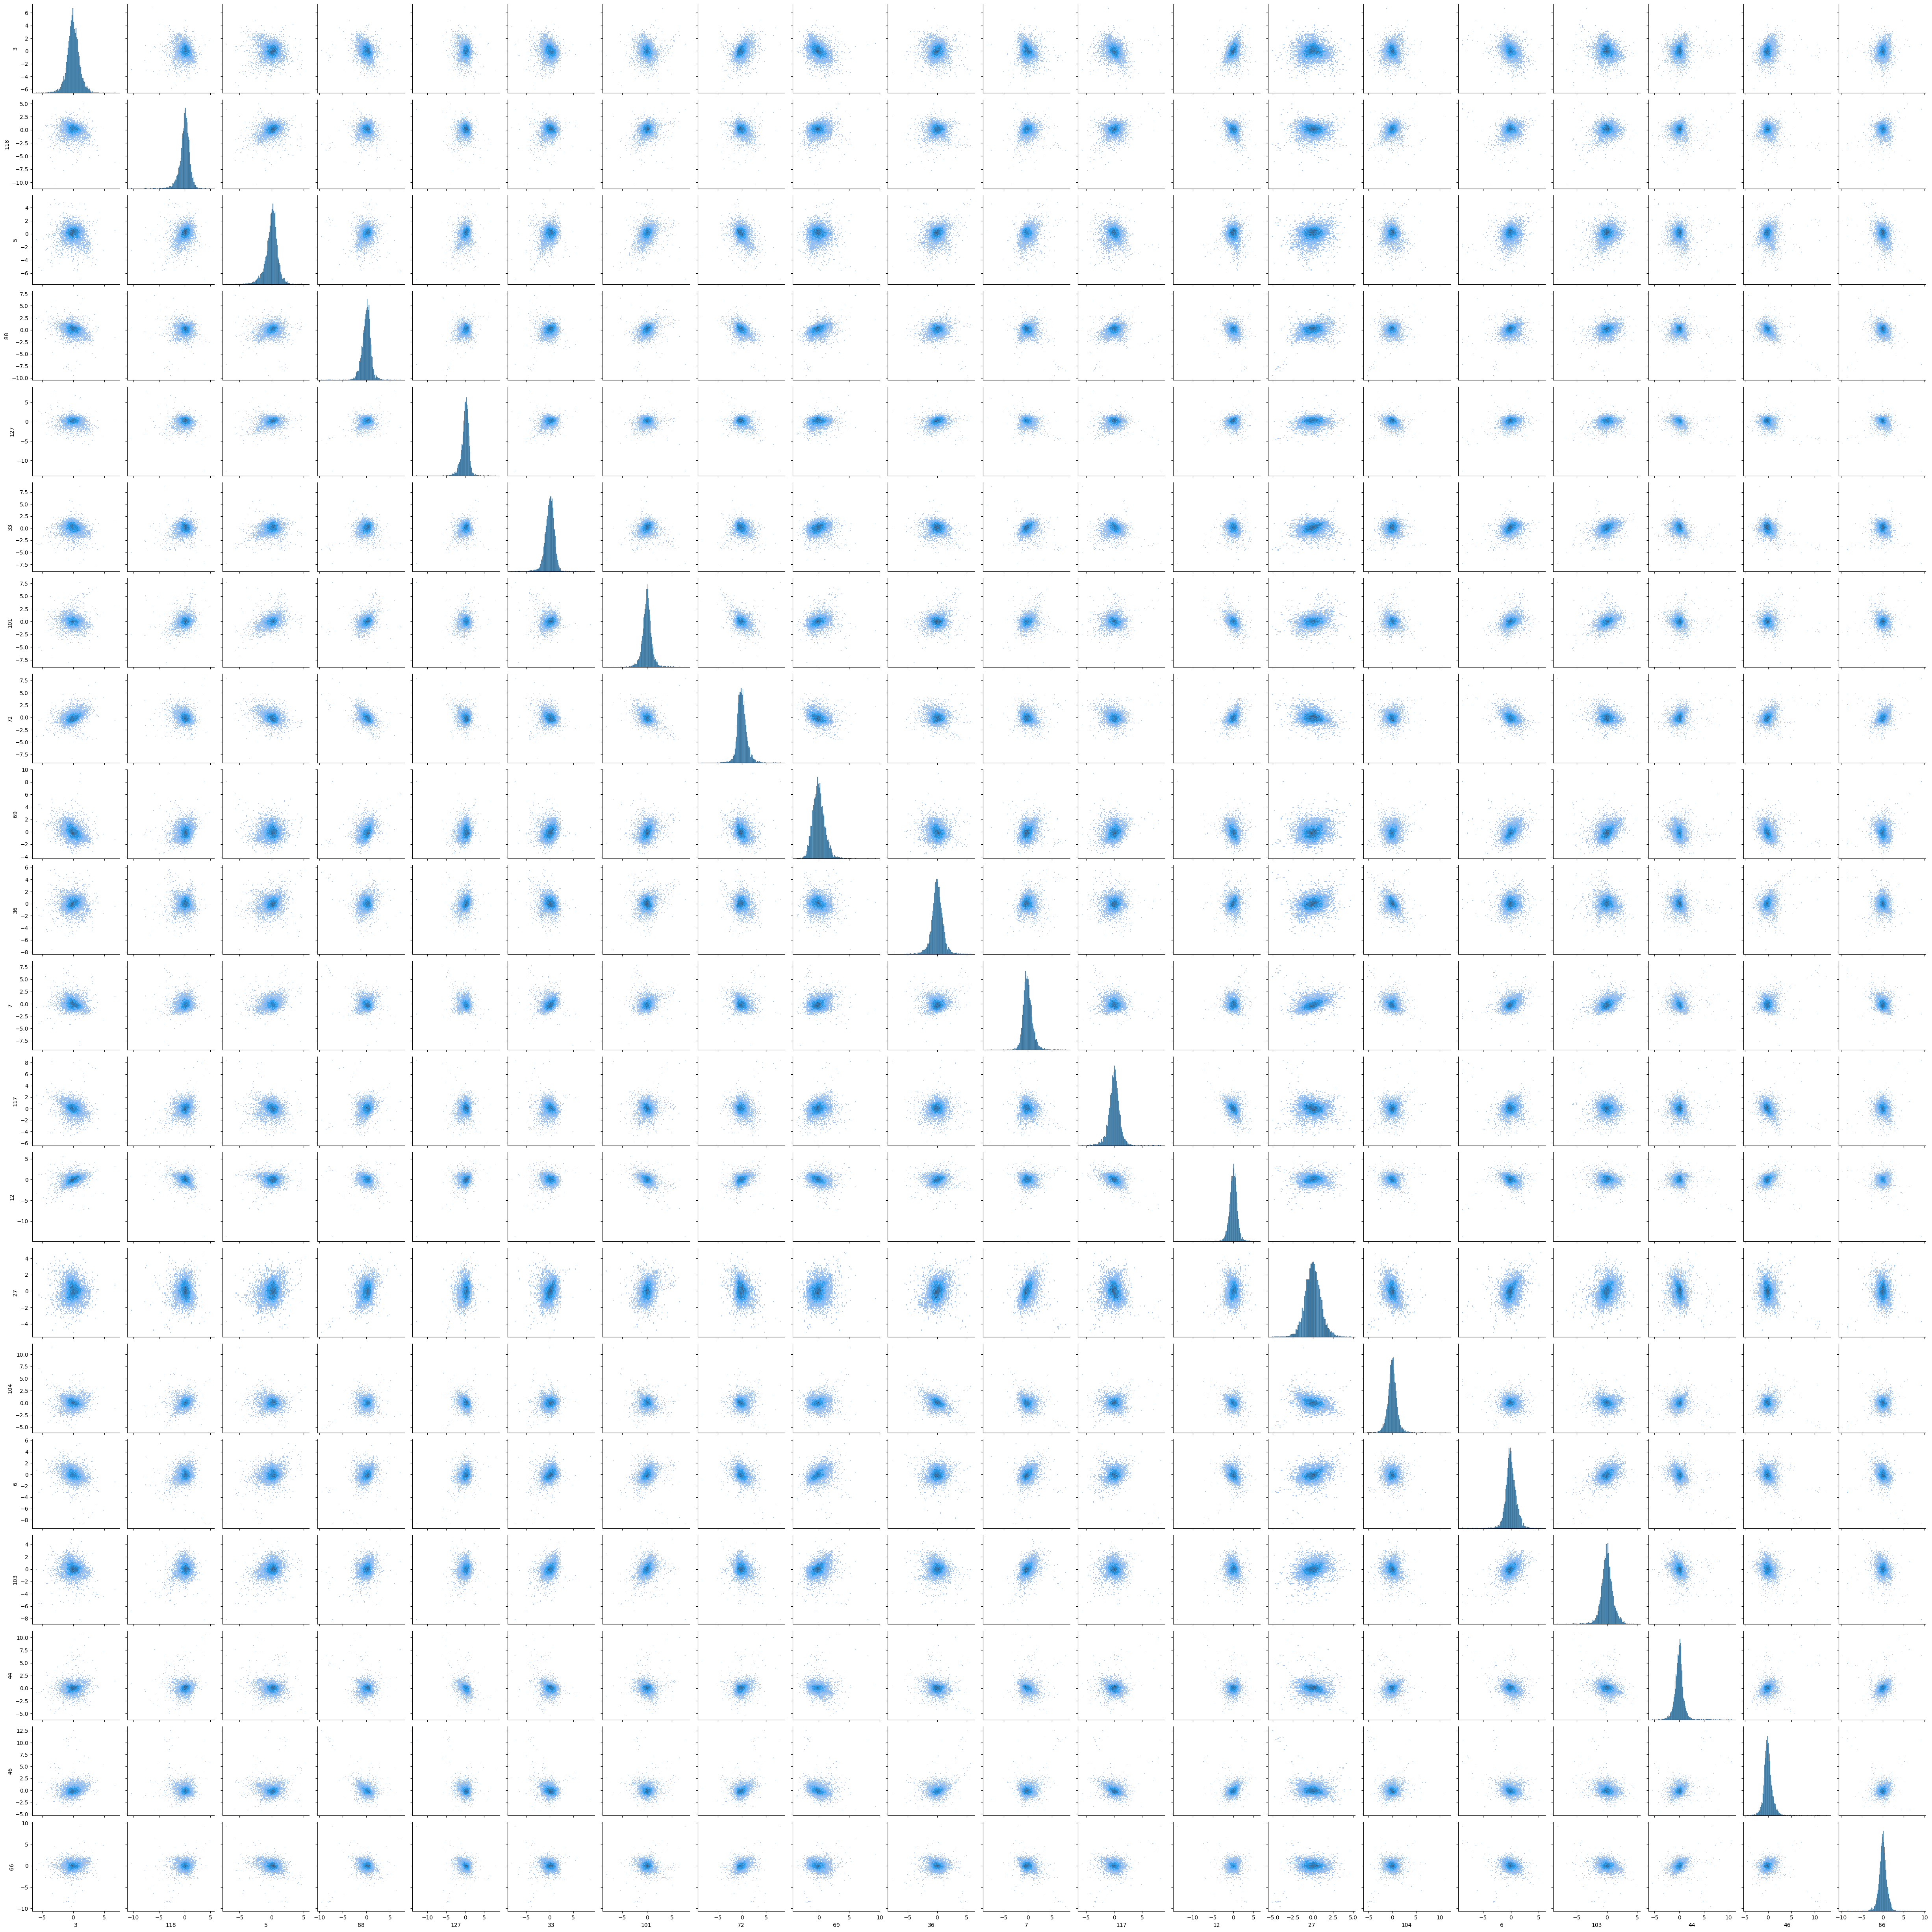

In [7]:
#KDE is extremely slow (5m+) even for just 5 features...
sns.pairplot(X_top_scaled, kind="hist", diag_kind="hist")
plt.show()

T3:
2) Batch gradient descent has the fastest epoch time but because it takes fewer overall steps since only one step is taken per epoch it requires many more epochs to converge. SGD has the slowest epoch time, especially because normally computations are vectorized but since only a single data point is used at a time this isn't possible to vectorize. Mini-batch gradient descent seems to be a solid balance of speed and convergence, particularly when using small batch sizes like 4-64. Epochs only take a few seconds but it still converges quickly down to about .1 loss, similarly to SGD (batch GD does not converge as low). When traversing the loss function, batch GD will have an accurate step in the direction of the true gradient whereas SGD will have the most noisy step since it is the gradient of just a single data point. Mini-batch GD will be a fair approximation of the true gradient, preventing overshooting like is possible with SGD but without all the computation required to compute a full batch of data. Since binary cross entropy is convex all of them should eventually converge to the global minimum. The paper by Sebastian Ruder confirms these observations-"SGD performs frequent updates with a high variance that cause the objective function to fluctuate heavily". "Batch gradient descent performs redundant computations for large datasets, as it recomputes gradients for similar examples before each parameter update. SGD does away with this redundancy by performing one update at a time. It is therefore usually much faster." As we know, the cost function is convex therefore they should all converge to the same minimum but SGD and mini-batch might jump around once they are at the minimum.

In [8]:
import math

def sigmoid(x):
    return 1/(1+np.exp(-x))

def infer(w, x):
    return sigmoid(x @ w)

def compute_grads(predicted,y,x):
    return 1.0/x.shape[0] * x.T @ (predicted-y)

def compute_loss(predicted,y):
    return -(y*np.log(predicted)+(1-y)*np.log(1-predicted))

class SGDOptimizer:
    def __init__(self,lr):
        self.learning_rate = lr

    def update(self, grads, weights):
        weights += grads * -self.learning_rate

class MomentumSGDOptimizer(SGDOptimizer):
    def __init__(self,lr,gam=0.9):
        SGDOptimizer.__init__(self, lr)
        self.gamma = gam
        self.momentum = None

    def update(self, grads, weights):
        if self.momentum is None:
            self.momentum = np.zeros(weights.shape[0]);

        v_t = self.gamma * self.momentum + self.learning_rate * grads
        weights -= v_t
        self.momentum = v_t

class AdamOptimizer(SGDOptimizer):
    def __init__(self,lr,beta1=.9,beta2=.999):
        SGDOptimizer.__init__(self, lr)
        self.beta1 = beta1
        self.beta2 = beta2
        self.ema_mean = None
        self.ema_var = None
        self.iteration = 1

    def update(self, grads, weights):
        if self.ema_mean is None:
            self.ema_mean = np.zeros(weights.shape[0]);
            self.ema_var = np.zeros(weights.shape[0]);

        m_t = self.beta1 * self.ema_mean + (1-self.beta1) * grads
        v_t = self.beta2 * self.ema_var + (1-self.beta2) * grads**2

        m_t_corrected = m_t/(1-self.beta1**self.iteration)
        v_t_corrected = v_t/(1-self.beta2**self.iteration)
        weights -= self.learning_rate / (np.sqrt(v_t_corrected) + 1e-8) * m_t_corrected

        self.ema_mean = m_t
        self.ema_var = v_t
        self.iteration += 1

class RMSPropOptimizer(SGDOptimizer):
    def __init__(self, lr, beta=0.9):
        super().__init__(lr)
        self.beta = beta
        self.ema_sq_grad = None

    def update(self, grads, weights):
        if self.ema_sq_grad is None:
            self.ema_sq_grad = np.zeros_like(weights)

        self.ema_sq_grad = self.beta * self.ema_sq_grad + (1 - self.beta) * grads**2
        weights -= self.learning_rate * grads / (np.sqrt(self.ema_sq_grad) + 1e-8)


def gradient_descent(epochs, x, y, optimizer, batch_size = float('inf')):
    n = x.shape[0]
    x = np.hstack([np.ones((n, 1)), x])
    weights = np.ones(x.shape[1])
    if batch_size < 1:
        batch_size = math.ceil(batch_size * n)

    for e in range(epochs):
        indices = np.random.permutation(n)
        x_shuffled = x[indices]
        y_shuffled = y[indices]

        start = 0
        e_loss = 0
        while start < n:
            end = min(start+batch_size, n)

            batch_x = x_shuffled[start:end]
            batch_y = y_shuffled[start:end]

            pred = infer(weights, batch_x);
            e_loss += np.mean(compute_loss(pred, batch_y)) * (end-start)/n
            grads = compute_grads(pred,batch_y,batch_x)
            optimizer.update(grads, weights)
            start += batch_size
        if e % 100 == 0 or e == epochs - 1:
            #print(f"Epoch {e+1}, Loss: {e_loss}")
            pass;
    return weights

def evaluate_params(test_x, test_y, params):
    n = test_x.shape[0]
    test_x = np.hstack([np.ones((n, 1)), test_x])
    pred = infer(params, test_x)
    pred_bin = (pred >= 0.5).astype(int)
    TP = np.sum((test_y == 1) & (pred_bin == 1))
    TN = np.sum((test_y == 0) & (pred_bin == 0))
    FP = np.sum((test_y == 0) & (pred_bin == 1))
    FN = np.sum((test_y == 1) & (pred_bin == 0))
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    print(f"accuracy: {accuracy} precision: {precision} recall: {recall} f1: {f1}")
    return accuracy, precision, recall, f1


def normalize_features(x, mean=None, std=None):
    if mean is None:
        mean = np.mean(x, axis=0)
    if std is None:
        std = np.std(x, axis=0)
        std[std == 0] = 1.0
    x_norm = (x - mean) / std
    return x_norm, mean, std


#X_train_norm, mean_train, std_train = normalize_features(X_train_final)
#X_test_norm, _, _ = normalize_features(X_test_final, mean_train, std_train)

#params = np.array([-4.56830118,-0.70322407,-0.00587972,0.32712297,0.95843659,-0.04862356,-0.68132557,-0.56463898,-0.47001344,0.41329871,-0.75060352,-1.4633638,-0.10163779,2.19433371,-0.62935575,0.10926888,-1.12106581,0.57643319,0.44127225,-0.02826334,-0.4708448,-1.07220332,-0.06104591,1.75621137,-0.63236876,0.53913135,-0.04242522,-0.01641342,0.05326739,0.34214654,-0.68829402,0.70574116,-0.67166513,-0.30939246,-0.13566353,-0.03716361,-0.27631546,-1.81031862,-0.74687124,1.072883,-0.11386899,0.72397502,-0.78188229,-1.27097748,-1.15376671,0.06933675,-0.01035446,0.79940583,-1.27226535,-0.34368277,-0.06987503,1.36252023,-1.28674124,-0.16133861,0.62861847,0.43475746,-1.31431501,-0.88595334,0.41800391,0.08207249,-1.07119047,0.11482361,-0.69353052,0.01526845,-1.62995243,1.41026281,0.24620917,1.04060077,2.10443248,-0.61226882,-1.79669863,-0.5945577,1.48188578,-1.63260143,-0.63548657,2.09127317,-0.11910852,-0.75146986,-1.21279571,-0.87647468,-0.77784051,-0.82490854,0.29320261,-0.9659483,-0.39781463,-0.09280856,-0.29802194,-0.59036979,-0.26297677,-0.27632562,-0.17855111,-0.38144305,0.35617465,1.09578962,0.1342286,-0.11964174,0.59524304,-0.63332618,-1.60161413,-1.41695257,1.34515961,0.31169533,-0.63998487,-1.37796326,0.11693218,0.11054567,0.12767131,0.39640917,-0.69827822,0.91690811,0.24697341,0.89660744,0.54121798,1.51724275,0.7961613,-0.14403667,-0.36616255,-0.34871627,-0.06964893,-1.54509091,1.07940189,-1.32534491,-0.10338277,-0.04711653,0.39300205,0.58843526,0.29810332,-0.39090912,-0.11147133,-0.92272237,-0.77760402,-1.03603751])

for o in [RMSPropOptimizer]:
    bestf1 = -12345
    bestf1_combo = [12345,12345]
    worstf1 = 12345
    worstf1_combo = [12345,12345]
    for lr in [0.2]:
        for bs in [float('inf')]:
            optim = o(lr)
            params = gradient_descent(2000,X_train_final,y_train_full,optim)
            _,_,_,f1 = evaluate_params(X_test_final, y_test, params)
            if f1 >= bestf1:
                bestf1_combo = [lr,bs]
                bestf1 = f1
            if f1 < worstf1:
                worstf1_combo = [lr,bs]
                worstf1 = f1
    print("best for "+ str(o)+" "+str(bestf1) + str(bestf1_combo))
    print("worst for "+ str(o)+" "+str(worstf1) + str(worstf1_combo))
print(params)

accuracy: 0.9664335664335665 precision: 0.8 recall: 0.14814814814814814 f1: 0.25
best for <class '__main__.RMSPropOptimizer'> 0.25[0.2, inf]
worst for <class '__main__.RMSPropOptimizer'> 0.25[0.2, inf]
[-1.46636141 -0.24381921  0.4039234   1.04180479  1.31744162 -0.47058783
 -1.0091921  -0.30651786 -0.93953925  2.09640498 -1.12064418 -2.67719381
  0.57704606  3.89577482 -1.29739395  1.45196668 -3.9284195   1.28290779
  1.13483139  1.71697338 -0.13802265 -2.08417589 -1.96452227  4.64301866
 -0.78738704  2.06969283 -1.00566052 -0.57130503  0.85669131  0.23980851
 -2.51314049  2.05215089 -1.59748043 -1.08191963  1.25670973 -0.57660452
  0.36795873 -5.94001723 -2.86770656  3.30635556 -1.57101952  2.41025428
 -1.0365582  -2.80540349 -2.74767189 -1.12006154  0.59669737  2.97257359
 -3.01487786 -0.55918178 -0.03451458  2.26709096 -3.45589023 -0.24855976
  2.84600162  1.24755283 -4.12707221 -1.9060546   0.13571199 -0.28250156
 -2.09916637  3.59446869 -3.73048349  0.06282754 -2.35977314  4.4502

T4)
1)(1000 epochs minibatch size=8 test) Normal SGD: gets to 0.107 loss and turning up the learning rate starts creating stability issues. Momentum converges to 0.1025 and also is much closer to this after just a few hundred epochs. Adam requires a lower learning rate and converges to 0.103. Both momentum and Adam converge to a low loss in much fewer steps than normal SGD which makes sense because they each make an effort to use an acceleration technique (momentum vs low variance) so that slopes of a loss curve can be descended quicker. RMSProp is actually more unstable than normal SGD and the loss tends to bottom out at around .117 which is worse than normal SGD. Overall everything but RMSProp seem to converge significantly faster than vanilla SGD.

2)
SGD LR=0.1 Minibatch:25% accuracy: 0.972027972027972 precision: 0.8181818181818182 recall: 0.3333333333333333 f1: 0.4736842105263157
MomentumSGD LR=0.04 Full Batch Epoch 10000, accuracy: 0.972027972027972 precision: 0.7692307692307693 recall: 0.37037037037037035 f1: 0.5
Adam Lr=0.005 Full Batch Epoch 10000, accuracy: 0.9664335664335665 precision: 0.5789473684210527 recall: 0.4074074074074074 f1: 0.47826086956521735
RMSProp LR=0.01 Full Batch Epoch 10000, accuracy: 0.9664335664335665 precision: 0.5882352941176471 recall: 0.37037037037037035 f1: 0.45454545454545453
accuracy - what % of the test points were correctly identified?
precision - what % of test points identified as a 1 were actually a 1?
recall - what % of 1 test points were identified as a 1?
f1 - overall score balancing precision and recall.

SGD with momentum performed best by a small margin, with SGD and Adam close behind but RMS prop trailing by a bit further. For momentum SGD the interpretation of the results is basically: it got 97.2% of the test data points correct. 76.9% of the time it output 1, the 1 was correct. Only 37% of the 1's in the test data set were correctly identified. A perfect model would have f1=1 so f1=0.5 is quite far away. This could make the model useful for identifying molecules that are likely to have AR activity - if it outputs a 1 then it is likely that the molecule has AR activity.

3) By hand tuning the model and after tuning LR and varying # of epochs (early stopping) to prevent degradation of generalization, I found that MomentumSGD was able to perform best-LR=0.04 Full Batch Epoch 10000, accuracy: 0.972027972027972 precision: 0.7692307692307693 recall: 0.37037037037037035 f1: 0.5. I previously focused on running for many epochs and although I got the loss to a lower value of around 1.01 the configuration above had a loss around 1.1. Additionally, I tried applying normalization to the data but that actually seemed to harm performance. My intution for this is that more important values for differentiating between classes already have a larger numerical difference since it is the output of an embedding model.

I consulted https://www.dremio.com/wiki/grid-search/ to implement grid search

I then used automated tuneing using a grid search on 4 learning rates (.001, .01, .04, .15) and 4 batch sizes (1,8,32,full) for 1000 epochs, using the f1 metric to determine best and worst configurations
best for SGDOptimizer f1=0.19047619047619047 lr=0.15 bs=inf
worst for SGDOptimizer f1=0.0 lr=0.001 bs=1
best for RMSPropOptimizer f1=0.4651162790697674 lr=0.15 bs=inf
worst for RMSPropOptimizer f1=0.39999999999999997 lr=0.15 bs=32
best for MomentumSGDOptimizer f1=0.45 lr=0.15 bs=inf
worst for MomentumSGDOptimizer f1=0.0 lr=0.001 bs=1
best for AdamOptimizer f1=0.4651162790697674 lr=0.15 bs=inf
worst for AdamOptimizer f1=0.21052631578947367 lr=0.001 bs=1

Clearly the choice of learning rate and batch size are very important. SGD and SGD with momentum are very sensitive to parameters, where if a poor set of parameters are selected then accuracy is very poor. However, we see that RMSProp is the most robust for a variety of hyperparameters with Adam following a bit behind with its worst performing at only f1=0.21. Interestingly the best across the board is using full-batch as well as lr=0.15. I then ran the grid search again with lrs=(0.15,0.25) for 2000 epochs.

best for SGDOptimizer f1=0.45 lr=0.25 bs=inf
worst for SGDOptimizer f1=0.4 lr=0.15 bs=1
best for MomentumSGDOptimizer f1=0.46153846153846156 lr=0.25 bs=inf
worst for MomentumSGDOptimizer f1=0.45 lr=0.15 bs=1
best for RMSPropOptimizer f1=0.5128205128205128 lr=0.25 bs=inf
worst for RMSPropOptimizer f1=0.25 lr=0.25 bs=32
best for AdamOptimizer f1=0.47619047619047616 lr=0.25 bs=32
worst for AdamOptimizer f1=0.4444444444444445 lr=0.15 bs=1

It's interesting that for adam the best performing used a bs=32 whereas in all other configurations full batch either matched or exceeded performance of smaller batch sizes. It seems that the worst performing models tend to be bs=1.
Seeing RMSProp's impressive performance, better than my hand tuning, I decided to focus on it. lrs=(0.2,.25,.3,.35) bs=(.5, full), epochs = 4000
best for RMSPropOptimizer f1=0.5365853658536585 lr=0.2 bs=inf
This is an impressive improvement over my hand tuned hyperparameters where I could only reach f1=.5 in 10,000 epochs.

5) Vanilla SGD is fast for each iteration since it is the most basic form of gradient descent without needing any optimizer state. However, it isn't very quick which means for complex problems like AI models time and power is wasted. SGD with momentum is faster since parameters on a surface with consistent slope will quickly converge. It will work well with large datasets especially at the beginning of training where the surface is well behaved and aggressive step sizes reduce the number of iterations needed. RMSProp is good for problems that require highly dynamic learning rate/unknown initial learning rate since it is adaptive. RMSProp is good for non-convex problems, RNNs and sparse data problems.(https://medium.com/@piyushkashyap045/understanding-rmsprop-a-simple-guide-to-one-of-deep-learnings-powerful-optimizers-403baeed9922). Adam is very robust since it can slow down on high variance topology/dimensions but speed up on low variance/smooth surfaces. And if it encounters a bump on a smooth surface it can still quickly pass it. Because of this its very efficient and well suited for many problems and only learning rate requires some tuning. Therefore it is good for large datasets.